In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [5]:
df = pd.read_csv(r"C:\Users\ravsi\Downloads\Conjunto de datos para 2a. evaluación-20260809\beisbol.csv")

In [6]:
print("Forma del dataset:", df.shape)
print("\nColumnas:", df.columns.tolist())
df.head()

Forma del dataset: (30, 4)

Columnas: ['Unnamed: 0', 'equipos', 'bateos', 'runs']


,Unnamed: 0,equipos,bateos,runs
0,0,Texas,5659,855
1,1,Boston,5710,875
2,2,Detroit,5563,787
3,3,Kansas,5672,730
4,4,St.,5532,762


In [7]:
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

In [8]:
print("Datos limpios:")
display(df.head())

Datos limpios:


,equipos,bateos,runs
0,Texas,5659,855
1,Boston,5710,875
2,Detroit,5563,787
3,Kansas,5672,730
4,St.,5532,762


In [9]:
print("\nEstadísticas descriptivas:")
display(df.describe())


Estadísticas descriptivas:


,bateos,runs
count,30.000000,30.000000
mean,5523.500000,693.600000
std,79.873067,82.479088
min,5417.000000,556.000000
25%,5448.250000,629.000000
50%,5515.500000,705.500000
75%,5575.000000,734.000000
max,5710.000000,875.000000


In [10]:
print("\nValores nulos por columna:")
print(df.isnull().sum())


Valores nulos por columna:
equipos    0
bateos     0
runs       0
dtype: int64


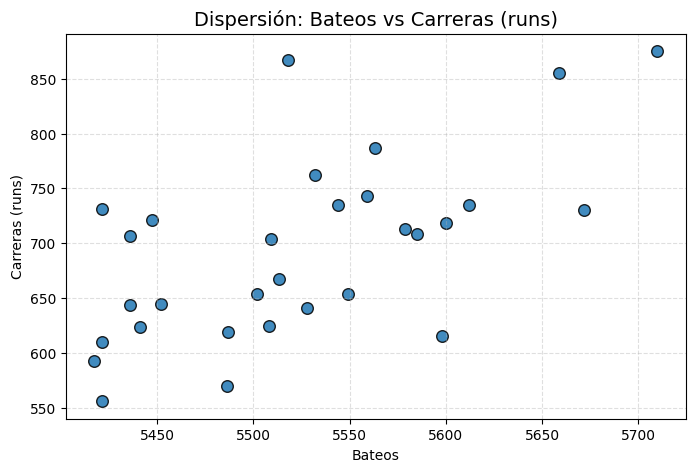

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(df["bateos"], df["runs"], color="#1f77b4", edgecolors="black", s=70, alpha=0.85)
plt.title("Dispersión: Bateos vs Carreras (runs)", fontsize=14)
plt.xlabel("Bateos")
plt.ylabel("Carreras (runs)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

In [12]:
print("Interpretación rápida:")
print("Se observa una tendencia: a más bateos, suelen aumentar las carreras.")
print("Hay algo de dispersión (ruido), por eso un modelo regularizado como Ridge es útil.")

Interpretación rápida:
Se observa una tendencia: a más bateos, suelen aumentar las carreras.
Hay algo de dispersión (ruido), por eso un modelo regularizado como Ridge es útil.


In [13]:
X = df[["bateos"]]
y = df["runs"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
print("Tamaño train:", X_train.shape[0])
print("Tamaño test :", X_test.shape[0])

Tamaño train: 24
Tamaño test : 6


In [16]:
modelo = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

In [17]:
param_grid = {
    "ridge__alpha": [0.01, 0.1, 1, 10, 50, 100, 200]
}

In [18]:
busqueda = GridSearchCV(
    modelo,
    param_grid=param_grid,
    cv=5,                 # validación cruzada
    scoring="r2",         # maximizar R²
    n_jobs=-1
)

In [19]:
busqueda.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...e', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ridge__alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, 

In [20]:
print("\nMejor alpha encontrado:", busqueda.best_params_["ridge__alpha"])
print("Mejor R² en validación cruzada:", round(busqueda.best_score_, 4))


Mejor alpha encontrado: 1
Mejor R² en validación cruzada: 0.2108


In [21]:
mejor_modelo = busqueda.best_estimator_

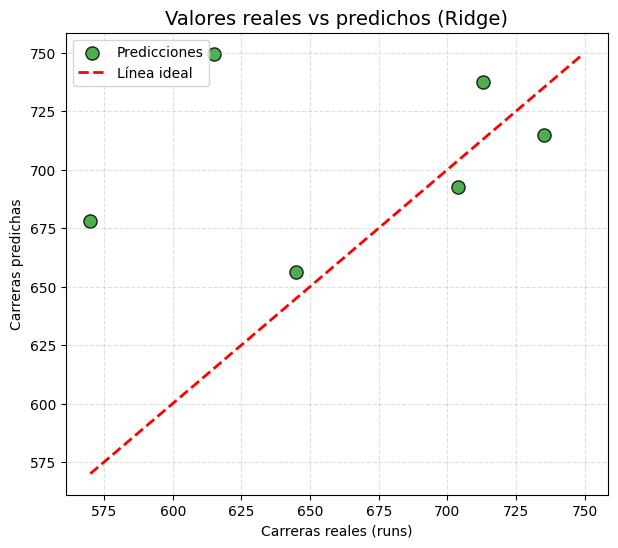

In [31]:
# GRAFICA COMPLETA (todo junto, obligatorio)

y_pred = mejor_modelo.predict(X_test)

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test, y_pred,
    color="#2ca02c",
    edgecolors="black",
    s=90,
    alpha=0.85,
    label="Predicciones"
)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="Línea ideal")

plt.title("Valores reales vs predichos (Ridge)", fontsize=14)
plt.xlabel("Carreras reales (runs)")
plt.ylabel("Carreras predichas")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

In [35]:
import pandas as pd

ejemplo = pd.DataFrame({"bateos": [5500]})
print("Predicción sin warning:", modelo_cargado.predict(ejemplo)[0])

Predicción sin warning: 686.7593767519471
